## Initial Imports

### library imports, path definitions

PosixPath('/home/lois/pypsa-eur/pypsa-damage')

### Network imports

In [3]:
# Paths
yr2008_s_path = f"{pypsa_eur_root}/results/2008-test-damage/networks/base_s_5_elec_.nc"
# yr2009_s_path = f"{pypsa_eur_root}/results/2009-test-source/networks/base_s_5___2030.nc"
# yr1995_s_path = f"{pypsa_eur_root}/results/1995-test-source/networks/base_s_5___2030.nc"

# Load networks
n08s = pypsa.Network(yr2008_s_path)
# n09s = pypsa.Network(yr2009_s_path)
# n95s = pypsa.Network(yr1995_s_path)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


In [4]:
n08s.snapshot_weightings

,objective,stores,generators
snapshot,,,
2008-03-01 00:00:00,1.0,1.0,1.0
2008-03-01 01:00:00,1.0,1.0,1.0
2008-03-01 02:00:00,1.0,1.0,1.0
2008-03-01 03:00:00,1.0,1.0,1.0
2008-03-01 04:00:00,1.0,1.0,1.0
...,...,...,...
2008-03-07 19:00:00,1.0,1.0,1.0
2008-03-07 20:00:00,1.0,1.0,1.0
2008-03-07 21:00:00,1.0,1.0,1.0


In [5]:
n08s.buses.columns

n08s.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,country,substation_lv,substation_off
name,,,,,,,,,,,,,,,,
BE0 0,380.0,,5.557658,50.710974,AC,,,1.0,0.0,inf,Slack,BE0 0 CCGT,0,BE,1.0,1.0
BE0 1,380.0,,4.363055,51.185520,AC,,,1.0,0.0,inf,PQ,,0,BE,1.0,1.0
BE0 2,380.0,,4.989686,50.808283,AC,,,1.0,0.0,inf,PQ,,0,BE,1.0,1.0
BE0 3,380.0,,5.723804,49.994754,AC,,,1.0,0.0,inf,PQ,,0,BE,1.0,1.0
BE0 4,380.0,,4.331467,50.658031,AC,,,1.0,0.0,inf,PQ,,0,BE,1.0,1.0
BE0 0 H2,1.0,,5.557658,50.710974,H2,,BE0 0,1.0,0.0,inf,PQ,,1,BE,NaN,NaN
BE0 1 H2,1.0,,4.363055,51.185520,H2,,BE0 1,1.0,0.0,inf,PQ,,2,BE,NaN,NaN
BE0 2 H2,1.0,,4.989686,50.808283,H2,,BE0 2,1.0,0.0,inf,PQ,,3,BE,NaN,NaN
BE0 3 H2,1.0,,5.723804,49.994754,H2,,BE0 3,1.0,0.0,inf,PQ,,4,BE,NaN,NaN


## check availability matrix

To get cf time-series per cluster, the availability matrix is used to get the weighted average of each cf time-series in the grid cell to the clustered cf time-series

In [24]:
AVAILABILITY_PATH = pypsa_eur_root / "resources/2008-test-damage/availability_matrix_5_onwind.nc"
availability_profile = xr.open_dataset(AVAILABILITY_PATH)
# Quick overview
print("=== Dataset Overview ===")
print(availability_profile)
print("\n=== Data Variables ===")
print(availability_profile.data_vars)
print("\n=== Dimensions ===")
print(availability_profile.dims)
print("\n=== Coordinates ===")
print(availability_profile.coords)

# Examine data

if "profile" in availability_profile:
    cf = cutout_profile["profile"]
    print(f"Shape: {cf.shape}")
    print(f"Mean: {cf.mean().values:.3f}")
    print(f"Max: {cf.max().values:.3f}")
    print(f"Min: {cf.min().values:.3f}")
    
    # Show first few timesteps for first location
    print("\n=== First 10 timesteps, first location ===")
    print(cf.isel(bus=0).head(10).values)

=== Dataset Overview ===
<xarray.Dataset> Size: 75kB
Dimensions:                        (bus: 5, y: 41, x: 45)
Coordinates:
  * bus                            (bus) <U5 100B 'BE0 0' 'BE0 1' ... 'BE0 4'
  * y                              (y) float64 328B 46.0 46.25 ... 55.75 56.0
  * x                              (x) float64 360B 4.0 4.25 4.5 ... 14.75 15.0
Data variables:
    __xarray_dataarray_variable__  (bus, y, x) float64 74kB ...

=== Data Variables ===
Data variables:
    __xarray_dataarray_variable__  (bus, y, x) float64 74kB ...

=== Dimensions ===
FrozenMappingWarningOnValuesAccess({'bus': 5, 'y': 41, 'x': 45})

=== Coordinates ===
Coordinates:
  * bus      (bus) <U5 100B 'BE0 0' 'BE0 1' 'BE0 2' 'BE0 3' 'BE0 4'
  * y        (y) float64 328B 46.0 46.25 46.5 46.75 ... 55.25 55.5 55.75 56.0
  * x        (x) float64 360B 4.0 4.25 4.5 4.75 5.0 ... 14.25 14.5 14.75 15.0


In [25]:
availability_profile_values = availability_profile['__xarray_dataarray_variable__'].values

In [26]:
availability_profile['__xarray_dataarray_variable__'].sel(bus='BE0 0').head(10)

<xarray.DataArray '__xarray_dataarray_variable__' (y: 10, x: 10)> Size: 800B
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
Coordinates:
    bus      <U5 20B 'BE0 0'
  * y        (y) float64 80B 46.0 46.25 46.5 46.75 ... 47.5 47.75 48.0 48.25
  * x        (x) float64 80B 4.0 4.25 4.5 4.75 5.0 5.25 5.5 5.75 6.0 6.25

In [27]:
availability_profile.sel(bus='BE0 4', y=50, x=4.25)['__xarray_dataarray_variable__']

<xarray.DataArray '__xarray_dataarray_variable__' ()> Size: 8B
array(0.202745)
Coordinates:
    bus      <U5 20B 'BE0 4'
    y        float64 8B 50.0
    x        float64 8B 4.25

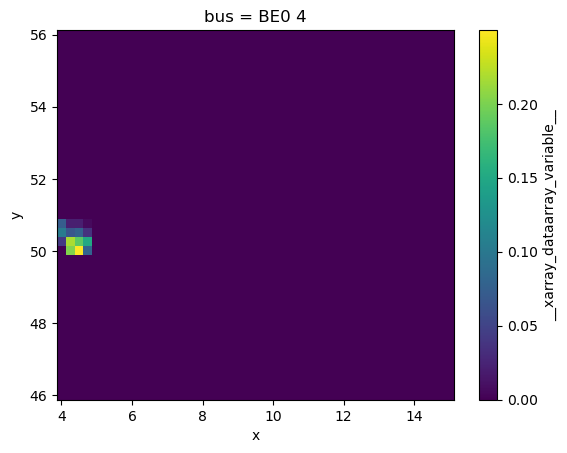

In [28]:
availability_profile['__xarray_dataarray_variable__'].sel(bus='BE0 4').plot()

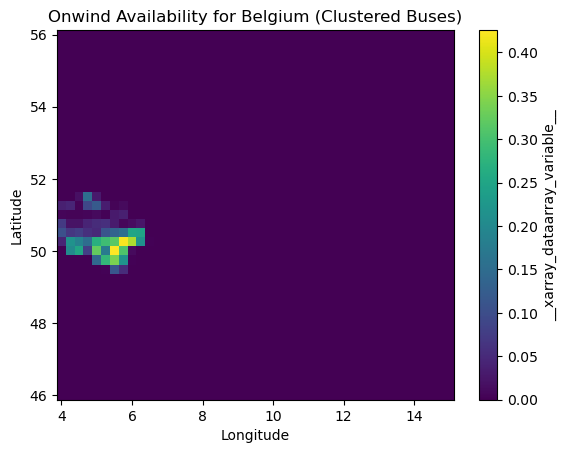

In [29]:
max_availability = availability_profile['__xarray_dataarray_variable__'].max(dim='bus')
max_availability.plot()
plt.title('Onwind Availability for Belgium (Clustered Buses)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [30]:
availability_profile_values.max()

np.float64(0.42562025616156607)

Availability matrix is a fraction for each grid cell (x,y) per bus. It is also an output from atlite. The fraction of the grid cell that can be used for the renewable source based on land-use constraint.

## Creating the damage mask, and replacing profile
1. Find all the grid cells within a bus cluster.
2. Filter for the relevant grid cells based on the availability matrix, specifically values that are greater than 0
3. For every bus, every timestep: 
    3.1 take the number of relevant grid cells within that bus that have wind speeds > a given threshold in m/s from the atlite cutout
    3.2 get the fraction by dividing by total number of relevant grid cells within that bus
4. Export as a "damage mask" file 
5. multiply to profile_[bus_number]_[wind technology].nc file as a new damaged profile.nc file

In [31]:
# ====================
# CONFIGURATION
# ====================
config_name = "2008-test-damage"
base_path = f"{pypsa_eur_root}/resources/{config_name}/networks/base_s_5_elec.nc"

NETWORK_PATH = f"{base_path}"
CUTOUT_PATH = cutout_path
DAMAGE_THRESHOLD = 15  # m/s
OUTPUT_PATH = f"{pypsa_eur_root}/resources/{config_name}/damage_onwind_fraction_mask.nc"

### Calculation

In [36]:
# ====================
# 1. LOAD DATA
# ====================
print("Loading network...")
n = pypsa.Network(NETWORK_PATH)
wind_gens = n.generators[n.generators.carrier.str.contains("onwind|offwind")]
wind_buses = wind_gens['bus'].unique()
print(f"  Found {len(wind_buses)} wind buses")

print("\nLoading cutout...")
cutout = atlite.Cutout(CUTOUT_PATH)
wind_speeds = cutout.data['wnd100m']

print("\nLoading availability matrix...")
availability = xr.open_dataarray(AVAILABILITY_PATH)
# only get cells that correspond to wind buses
availability_wind = availability.sel(bus=wind_buses)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


Loading network...
  Found 5 wind buses

Loading cutout...

Loading availability matrix...


In [37]:
# ====================
# 2-3. CALCULATE DAMAGE FRACTIONS
# ====================
print(f"\nCalculating damage fractions (threshold: {DAMAGE_THRESHOLD} m/s)...")

damage_fractions = []

for bus in wind_buses:
    # Get relevant grid cells (availability > 0)
    spatial_weights = availability_wind.sel(bus=bus)
    relevant_cells = spatial_weights > 0
    n_relevant = relevant_cells.sum().values
    
    if n_relevant == 0:
        # No relevant cells - no damage possible
        bus_fraction = xr.DataArray(
            np.zeros(len(wind_speeds.time)),
            dims=['time'],
            coords={'time': wind_speeds.time}
        )
    else:
        # Count damaged cells per timestep
        grid_damage = (wind_speeds >= DAMAGE_THRESHOLD).astype(float)
        relevant_cells_broadcast = relevant_cells.broadcast_like(grid_damage)
        damage_in_relevant = grid_damage.where(relevant_cells_broadcast, 0)
        n_damaged_per_time = damage_in_relevant.sum(dim=['y', 'x'])
        
        # Calculate fraction
        bus_fraction = n_damaged_per_time / n_relevant
    
    damage_fractions.append(bus_fraction)

# Check calculation for last bus
print(f"\nSample results for bus: {bus}")
print(f"number of relevant cells: {n_relevant}")
print(f"damaged relevant cells timesteps: {n_damaged_per_time.values[:15]}")
print(f"bus_fraction timesteps: {bus_fraction.values[:15]}")


Calculating damage fractions (threshold: 15 m/s)...

Sample results for bus: BE0 4
number of relevant cells: 16
damaged relevant cells timesteps: [16. 16. 16. 16. 16. 16. 16. 14. 10.  0. 10. 15.  5.  0.  0.]
bus_fraction timesteps: [1.     1.     1.     1.     1.     1.     1.     0.875  0.625  0.
 0.625  0.9375 0.3125 0.     0.    ]


In [38]:
# Convert to operational mask (1.0 = fully operational, 0.0 = fully damaged)
operational_mask = 1.0 - xr.concat(damage_fractions, dim=pd.Index(wind_buses, name='bus'))
if operational_mask.dims == ('bus', 'time'):
    operational_mask = operational_mask.transpose('time', 'bus')

print(f"\nOperational mask shape: {operational_mask.shape}")
print(f"Overall avg operational fraction: {operational_mask.mean().values:.3f}")

print(f"\nSaving to: {OUTPUT_PATH}")
operational_mask.to_netcdf(OUTPUT_PATH)
print("✓ Done!")


Operational mask shape: (192, 5)
Overall avg operational fraction: 0.935

Saving to: /home/lois/pypsa-eur/pypsa-eur/resources/2008-test-damage/damage_onwind_fraction_mask.nc
✓ Done!


### Plotting damage using voronoi cells and atlite cutout

In [39]:
import geopandas as gpd
import matplotlib.pyplot as plt

<Axes: >

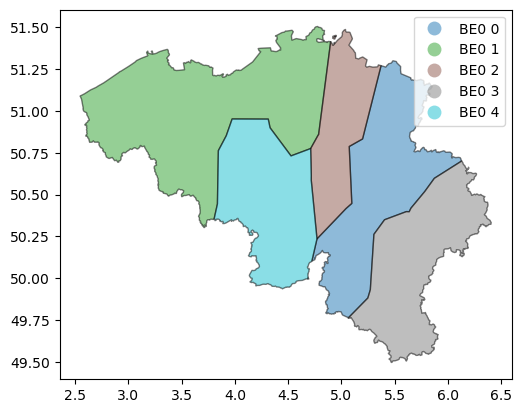

In [40]:
geojson_path=f"{pypsa_eur_root}/resources/{config_name}/regions_onshore_base_s_5.geojson"

regions = gpd.read_file(geojson_path)

regions.plot(column='name', edgecolor='black', alpha=0.5, legend=True)


interactive(children=(SelectionSlider(continuous_update=False, description='Timestamp:', options=(('2008-03-01…

<function __main__.interactive_damage_plot(timestep)>

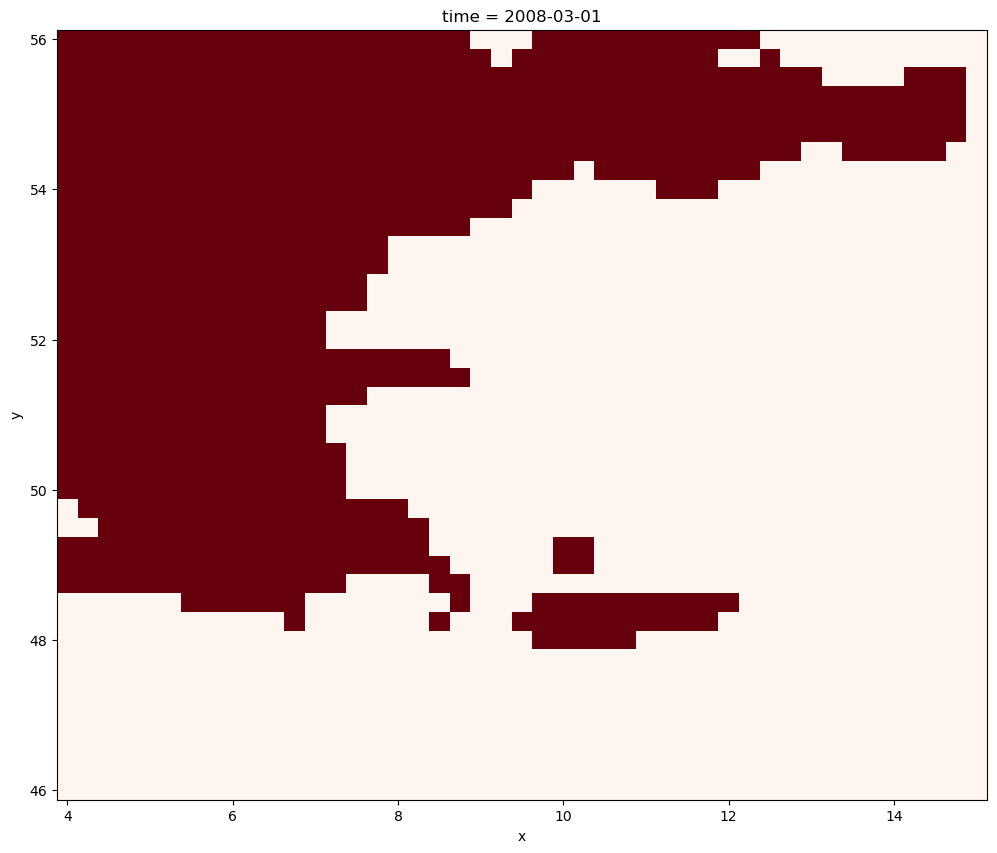

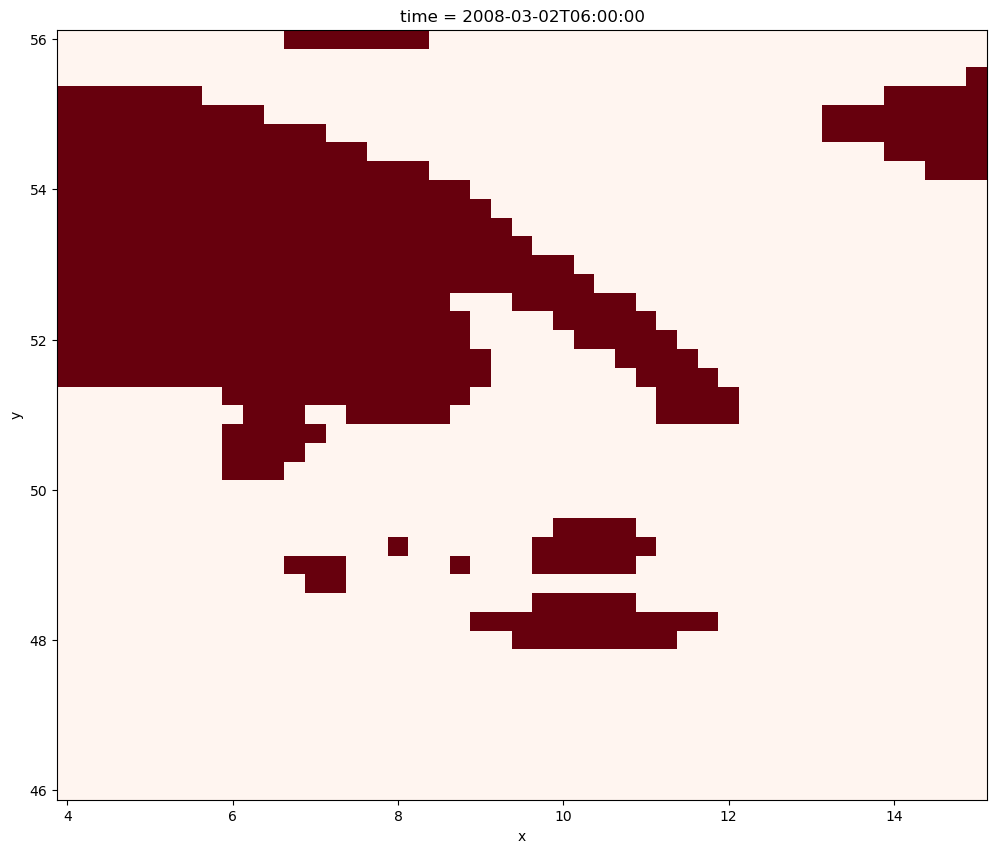

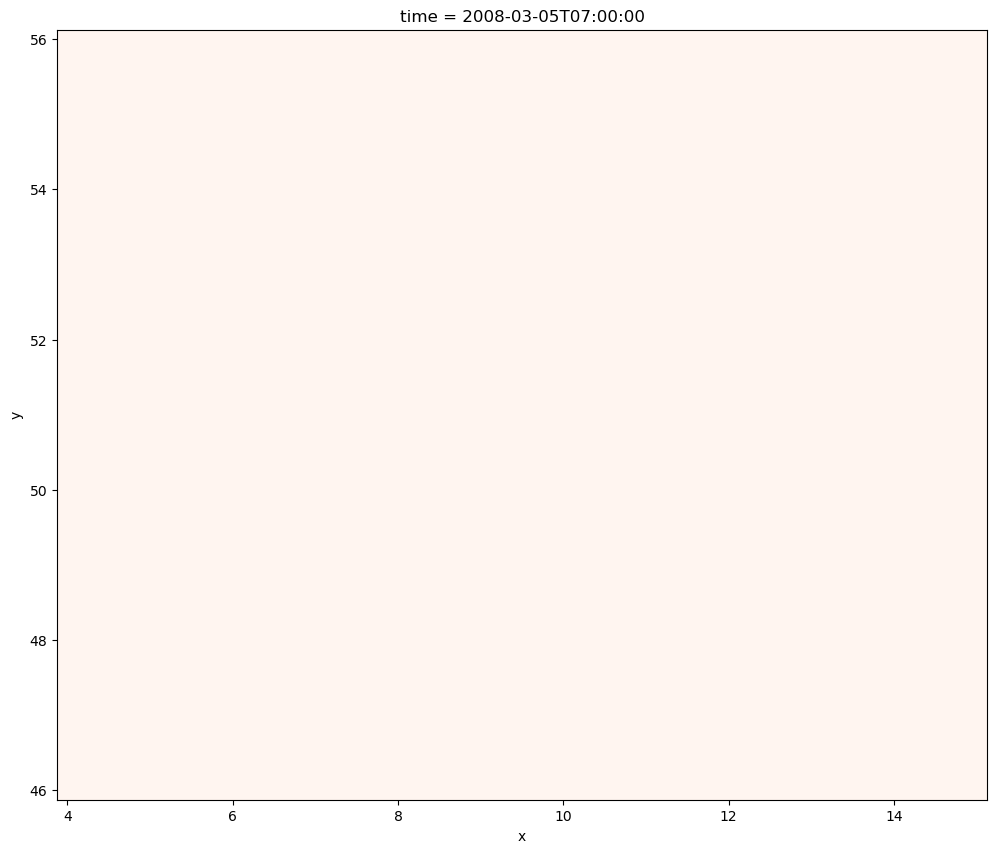

In [41]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Interactive widget with timestamp labels
from ipywidgets import interact, SelectionSlider
import pandas as pd

def plot_damage_at_timestep(timestep_idx, damage_threshold=DAMAGE_THRESHOLD,
                            geojson_path="pypsa-eur/resources/2008-test-source/regions_onshore_base_s_5.geojson"):
    """
    Visualize damaged grid cells and bus regions from GeoJSON at a specific timestep.
    
    Parameters:
    - timestep_idx: int, index of timestep to visualize (0 to len(time)-1)
    - geojson_path: str, path to regions GeoJSON file
    """
    
    # Get damage at this timestep
    damage_at_time = wind_speeds.isel(time=timestep_idx) >= damage_threshold
    timestamp = wind_speeds.time.isel(time=timestep_idx).values
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot damaged cells
    damage_at_time.plot(ax=ax, cmap='Reds', add_colorbar=False, vmin=0, vmax=1)
    
    # Load and plot GeoJSON regions
    regions = gpd.read_file(f"{root}/../../{geojson_path}")
    
    # Filter to only wind buses if possible
    if 'name' in regions.columns:
        regions_wind = regions[regions['name'].isin(wind_buses)]
    else:
        regions_wind = regions
    
    # Plot region boundaries
    regions_wind.boundary.plot(ax=ax, linewidth=2, edgecolor='blue')
    
    # Label regions
    for idx, row in regions_wind.iterrows():
        centroid = row.geometry.centroid
        label = row.get('name', f'Region {idx}')
        ax.text(centroid.x, centroid.y, label, fontsize=8, 
               ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    ax.set_title(f'Damaged Grid Cells (>{damage_threshold} m/s)\nTimestep: {timestamp}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    plt.tight_layout()
    return fig

# Create timestamp labels
timestamps = pd.to_datetime(wind_speeds.time.values)
timestamp_labels = [(str(ts), i) for i, ts in enumerate(timestamps)]

def interactive_damage_plot(timestep):
    fig = plot_damage_at_timestep(timestep, damage_threshold=DAMAGE_THRESHOLD)
    plt.show()

# Create interactive widget with timestamp selector
interact(interactive_damage_plot, 
         timestep=SelectionSlider(
             options=timestamp_labels,
             description='Timestamp:',
             continuous_update=False
         ))

## Apply damage mask to onwind profile

In [42]:
PROFILE_PATH = f"{pypsa_eur_root}/resources/{config_name}/profile_5_onwind.nc"
OUTPUT_DAMAGED_PROFILE_PATH = f"{pypsa_eur_root}/resources/{config_name}/profile_5_onwind_damaged.nc"

print("\nLoading original profile...")
profile_ds = xr.open_dataset(PROFILE_PATH)
print(f"  Profile shape: {profile_ds['profile'].shape}")
print(f"  Profile dimensions: {profile_ds['profile'].dims}")


Loading original profile...
  Profile shape: (1, 168, 5, 1)
  Profile dimensions: ('year', 'time', 'bus', 'bin')


In [43]:
# ====================
# 6. APPLY MASK TO PROFILE
# ====================
PROFILE_PATH = f"{pypsa_eur_root}/resources/{config_name}/profile_5_onwind.nc"
OUTPUT_DAMAGED_PROFILE_PATH = f"{pypsa_eur_root}/resources/{config_name}/profile_5_onwind_damaged.nc"

print("\nLoading original profile...")
profile_ds = xr.open_dataset(PROFILE_PATH)
print(f"  Profile shape: {profile_ds['profile'].shape}")
print(f"  Profile dimensions: {profile_ds['profile'].dims}")

print("\nApplying operational mask...")
# Multiply profile by operational mask (broadcasting handles dimension alignment)
damaged_profile = profile_ds.copy()
damaged_profile['profile'] = profile_ds['profile'] * operational_mask

# Statistics
original_mean = profile_ds['profile'].mean().values
damaged_mean = damaged_profile['profile'].mean().values
reduction_pct = 100 * (1 - damaged_mean / original_mean)

print(f"  Original mean capacity factor: {original_mean:.4f}")
print(f"  Damaged mean capacity factor: {damaged_mean:.4f}")
print(f"  Overall reduction: {reduction_pct:.2f}%")

print(f"\nSaving damaged profile to: {OUTPUT_DAMAGED_PROFILE_PATH}")
damaged_profile.to_netcdf(OUTPUT_DAMAGED_PROFILE_PATH)
print("✓ Done!")


Loading original profile...
  Profile shape: (1, 168, 5, 1)
  Profile dimensions: ('year', 'time', 'bus', 'bin')

Applying operational mask...
  Original mean capacity factor: 0.4563
  Damaged mean capacity factor: 0.3820
  Overall reduction: 16.28%

Saving damaged profile to: /home/lois/pypsa-eur/pypsa-eur/resources/2008-test-damage/profile_5_onwind_damaged.nc
✓ Done!


## Check damaged optimization results

In [32]:
elec_base_path = f"{pypsa_eur_root}/results/{config_name}/networks/base_s_5_elec_.nc" 
elec_damaged_dispatch_path = f"{pypsa_eur_root}/results/{config_name}/networks/base_s_5_elec__damaged-dispatch.nc" 
elec_damaged_cap_path = f"{pypsa_eur_root}/results/{config_name}/networks/base_s_5_elec_damaged.nc" 

n_b = pypsa.Network(elec_base_path)

n_dd = pypsa.Network(elec_damaged_dispatch_path)

n_dc = pypsa.Network(elec_damaged_cap_path)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


In [33]:
# Export statistics to CSV
n_b_stats = n_b.statistics()
n_b_stats.to_csv('n_b_statistics.csv')

n_dd_stats = n_dd.statistics()
n_dd_stats.to_csv('n_dd_statistics.csv')

n_dc_stats = n_dc.statistics()
n_dc_stats.to_csv('n_dc_statistics.csv')

In [77]:
n_b.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        5078.30000          5078.30000   
            Onshore Wind              2411.00000          2411.00000   
            Solar                     5453.00000          5453.00000   
            biomass                     75.00000            75.00000   
            nuclear                   5919.00000          5919.00000   
            oil                        126.60000           126.60000   
Line        AC                       20868.79214         20868.79214   
Load        -                            0.00000             0.00000   
StorageUnit Battery Storage           2187.04316             0.00000   

                                      Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas  647967.36644  0.000000e+00    6.479674e+05   
            Onshore Wind        185387.71178  0.000000e+00    1.853877e+05   
            Solar               107222.32699  0.000000e+00    1.072223e+05   
            biomass              12600.00000  0.000000e+00    1.260000e+04   
            nuclear             878048.13600  0.000000e+00    8.780481e+05   
            oil                   7089.60000  0.000000e+00    7.089600e+03   
Line        AC                    9772.59595  5.178001e+05   -5.080275e+05   
Load        -                        0.00000  1.836755e+06   -1.836755e+06   
StorageUnit Battery Storage      37443.38597  3.900353e+04   -1.560141e+03   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas       0.00000         0.759496  205187.03356   
            Onshore Wind             0.00000         0.457693       0.00000   
            Solar                    0.00000         0.117042       0.00000   
            biomass                  0.00000         1.000000       0.00000   
            nuclear                  0.00000         0.883000       0.00000   
            oil                      0.00000         0.333333   14179.20000   
Line        AC                  508027.50536         0.150479       0.00000   
Load        -                        0.00000              NaN       0.00000   
StorageUnit Battery Storage          0.00000         0.208062  368983.39223   

                                Capital Expenditure  Operational Expenditure  \
Generator   Combined-Cycle Gas         9.754691e+06             2.928096e+07   
            Onshore Wind               4.352369e+06             4.569809e+03   
            Solar                      3.068927e+06             2.125234e+03   
            biomass                    4.231659e+05             1.995622e+05   
            nuclear                    8.556587e+07             1.231326e+07   
            oil                        9.487992e+04             1.116850e+06   
Line        AC                         1.205876e+06             0.000000e+00   
Load        -                          0.000000e+00             0.000000e+00   
StorageUnit Battery Storage            2.022569e+06             3.663549e+02   

                                     Revenue  Market Value  
Generator   Combined-Cycle Gas  7.387860e+07    114.015920  
            Onshore Wind        1.206733e+07     65.092396  
            Solar               8.241773e+06     76.866203  
            biomass             1.228031e+06     97.462742  
            nuclear             8.557698e+07     97.462742  
            oil                 1.428335e+06    201.469069  
Line        AC                 -4.325156e+07  -4425.800854  
Load        -                  -1.844440e+08           NaN  
StorageUnit Battery Storage     2.022935e+06     54.026496

In [78]:
n_dc.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        5078.30000          5078.30000   
            Onshore Wind              2411.00000          2411.00000   
            Solar                     5453.00000          5453.00000   
            biomass                     75.00000            75.00000   
            nuclear                   5919.00000          5919.00000   
            oil                        126.60000           126.60000   
Line        AC                       20868.79214         20868.79214   
Load        -                            0.00000             0.00000   
StorageUnit Battery Storage           2187.04316             0.00000   

                                      Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas  678434.01343  0.000000e+00    6.784340e+05   
            Onshore Wind        154921.06478  0.000000e+00    1.549211e+05   
            Solar               107222.32699  0.000000e+00    1.072223e+05   
            biomass              12600.00000  0.000000e+00    1.260000e+04   
            nuclear             878048.13600  0.000000e+00    8.780481e+05   
            oil                   7089.60000  0.000000e+00    7.089600e+03   
Line        AC                   25555.75039  3.955824e+05   -3.700266e+05   
Load        -                        0.00000  1.836755e+06   -1.836755e+06   
StorageUnit Battery Storage      37443.38597  3.900353e+04   -1.560141e+03   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas       0.00000         0.795207  174720.38657   
            Onshore Wind             0.00000         0.382476       0.00000   
            Solar                    0.00000         0.117042       0.00000   
            biomass                  0.00000         1.000000       0.00000   
            nuclear                  0.00000         0.883000       0.00000   
            oil                      0.00000         0.333333   14179.20000   
Line        AC                  370026.64182         0.120121       0.00000   
Load        -                        0.00000              NaN       0.00000   
StorageUnit Battery Storage          0.00000         0.208062  368983.39223   

                                Capital Expenditure  Operational Expenditure  \
Generator   Combined-Cycle Gas         9.754691e+06             3.065816e+07   
            Onshore Wind               4.352369e+06             3.839305e+03   
            Solar                      3.068927e+06             2.172775e+03   
            biomass                    4.231659e+05             1.995625e+05   
            nuclear                    8.556587e+07             1.231280e+07   
            oil                        9.487992e+04             1.116855e+06   
Line        AC                         1.205876e+06             0.000000e+00   
Load        -                          0.000000e+00             0.000000e+00   
StorageUnit Battery Storage            2.022569e+06             3.456488e+02   

                                     Revenue  Market Value  
Generator   Combined-Cycle Gas  7.525566e+07    110.925547  
            Onshore Wind        1.069068e+07     69.007260  
            Solar               8.241839e+06     76.866818  
            biomass             1.228037e+06     97.463278  
            nuclear             8.557745e+07     97.463278  
            oil                 1.428340e+06    201.469723  
Line        AC                 -4.104080e+07  -1605.932163  
Load        -                  -1.844449e+08           NaN  
StorageUnit Battery Storage     2.022914e+06     54.025943

In [79]:
n_dd.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        5078.30000          5078.30000   
            Onshore Wind              2411.00000          2411.00000   
            Solar                     5453.00000          5453.00000   
            biomass                     75.00000            75.00000   
            load_shedding              234.54144             0.00000   
            nuclear                   5919.00000          5919.00000   
            oil                        126.60000           126.60000   
Line        AC                       20868.79214         20868.79214   
Load        -                            0.00000             0.00000   
StorageUnit Battery Storage           2187.04316          2187.04316   

                                      Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas  678615.39262  0.000000e+00    6.786154e+05   
            Onshore Wind        154921.06478  0.000000e+00    1.549211e+05   
            Solar               107222.32699  0.000000e+00    1.072223e+05   
            biomass              12600.00000  0.000000e+00    1.260000e+04   
            load_shedding          258.46640  0.000000e+00    2.584664e+02   
            nuclear             878048.13600  0.000000e+00    8.780481e+05   
            oil                   7089.60000  0.000000e+00    7.089600e+03   
Line        AC                   17014.86131  4.256273e+05   -4.086124e+05   
Load        -                        0.00000  1.836755e+06   -1.836755e+06   
StorageUnit Battery Storage      37374.70704  3.893199e+04   -1.557279e+03   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas       0.00000         0.795419  174539.00738   
            Onshore Wind             0.00000         0.382476       0.00000   
            Solar                    0.00000         0.117042       0.00000   
            biomass                  0.00000         1.000000       0.00000   
            load_shedding            0.00000         0.006560   39144.49559   
            nuclear                  0.00000         0.883000       0.00000   
            oil                      0.00000         0.333333   14179.20000   
Line        AC                  408612.44682         0.126254       0.00000   
Load        -                        0.00000              NaN       0.00000   
StorageUnit Battery Storage          0.00000         0.207681  368980.53060   

                                Capital Expenditure  Operational Expenditure  \
Generator   Combined-Cycle Gas         9.754691e+06             3.067266e+07   
            Onshore Wind               4.352369e+06             5.324835e+03   
            Solar                      3.068927e+06             3.165605e+03   
            biomass                    4.231659e+05             1.996841e+05   
            load_shedding              0.000000e+00             2.584666e+06   
            nuclear                    8.556587e+07             1.232219e+07   
            oil                        9.487992e+04             1.116921e+06   
Line        AC                         1.338936e+06             0.000000e+00   
Load        -                          0.000000e+00             0.000000e+00   
StorageUnit Battery Storage            2.022569e+06             7.215173e+02   

                                     Revenue  Market Value  
Generator   Combined-Cycle Gas  2.758749e+09   4065.261666  
            Onshore Wind        2.327121e+08   1502.133152  
            Solar               2.137249e+08   1993.287396  
            biomass             4.079908e+07   3238.022414  
            load_shedding       2.584666e+06  10000.012740  
            nuclear             2.842721e+09   3237.545965  
            oil                 6.850046e+07   9662.104825  
Line        AC                 -1.258615e+09 -73971.529049  
Load        -                  -6.295377e+09           NaN  
StorageUnit Battery

In [50]:
n_b.generators.p_nom

name
BE0 0 CCGT             513.000000
BE0 0 biomass           30.000000
BE0 0 nuclear         3008.000000
BE0 1 CCGT            2693.300000
BE0 1 biomass           45.000000
BE0 1 nuclear         2911.000000
BE0 1 oil               72.000000
BE0 2 CCGT             465.000000
BE0 3 oil               18.000000
BE0 4 CCGT            1407.000000
BE0 4 oil               36.600000
BE0 0 0 solar-hsat       0.000000
BE0 1 0 solar-hsat       0.000000
BE0 2 0 solar-hsat       0.000000
BE0 3 0 solar-hsat       0.000000
BE0 4 0 solar-hsat       0.000000
BE0 0 0 onwind         446.480910
BE0 1 0 onwind         651.730981
BE0 2 0 onwind         337.549218
BE0 3 0 onwind         524.871577
BE0 4 0 onwind         450.367314
BE0 0 0 solar         1248.786451
BE0 1 0 solar         1285.084744
BE0 2 0 solar          848.511007
BE0 3 0 solar          704.429830
BE0 4 0 solar         1366.187968
Name: p_nom, dtype: float64

In [67]:
n_dc.generators[n_dc.generators.carrier.str.contains("load", case=False)]

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,


In [ ]:
n_dc.generators[n_dc.generators.carrier.str.contains("load", case=False)]

In [57]:
n_dd.generators.p_nom_opt

name
BE0 0 CCGT             513.000000
BE0 0 biomass           30.000000
BE0 0 nuclear         3008.000000
BE0 1 CCGT            2693.300000
BE0 1 biomass           45.000000
BE0 1 nuclear         2911.000000
BE0 1 oil               72.000000
BE0 2 CCGT             465.000000
BE0 3 oil               18.000000
BE0 4 CCGT            1407.000000
BE0 4 oil               36.600000
BE0 0 0 solar-hsat       0.000000
BE0 1 0 solar-hsat       0.000000
BE0 2 0 solar-hsat       0.000000
BE0 3 0 solar-hsat       0.000000
BE0 4 0 solar-hsat       0.000000
BE0 0 0 onwind         446.480910
BE0 1 0 onwind         651.730981
BE0 2 0 onwind         337.549218
BE0 3 0 onwind         524.871577
BE0 4 0 onwind         450.367314
BE0 0 0 solar         1248.786451
BE0 1 0 solar         1285.084744
BE0 2 0 solar          848.511007
BE0 3 0 solar          704.429830
BE0 4 0 solar         1366.187968
Name: p_nom_opt, dtype: float64

## Check differences between .nc files
Need to know at which stage to change h ep_max_pu values

In [ ]:
# yr2008_base_path = f"{pypsa_eur_root}/resources/2008-test-source/networks/base.nc" 
# yr2008_base_s_path = f"{pypsa_eur_root}/resources/2008-test-source/networks/base_s.nc" 
# yr2008_base_s_5_path = f"{pypsa_eur_root}/resources/2008-test-source/networks/base_s_5.nc" 
# yr2008_base_s_5_elec_path = f"{pypsa_eur_root}/resources/2008-test-source/networks/base_s_5_elec.nc" 
# yr2008_base_s_5_elec__path = f"{pypsa_eur_root}/resources/2008-test-source/networks/base_s_5_elec_.nc" 
# yr2008_base_s_5___2030_path = f"{pypsa_eur_root}/resources/2008-test-source/networks/base_s_5___2030.nc" 
# yr2008_base_extended = f"{pypsa_eur_root}/resources/2008-test-source/networks/base_extended.nc" 


n_base = ps.Network(yr2008_base_s_5_elec_path)
n_base_ = ps.Network(yr2008_base_s_5_elec__path)
n_base_2030 = ps.Network(yr2008_base_s_5___2030_path)

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, stores, sub_networks


In [30]:
yr2008_base_s_5_elec_path = f"{pypsa_eur_root}/results/2008-test-source/networks/base_s_5_elec_.nc"
yr2008_base_s_5_elec_damaged_path = f"{pypsa_eur_root}/results/2008-test-source/networks/base_s_5_elec_damaged.nc" 

In [61]:
def compare_networks_detailed(path1, path2, name1='Network 1', name2='Network 2'):
    n1 = pypsa.Network(path1)
    n2 = pypsa.Network(path2)
    
    print(f"\nComparing {name1} vs {name2}")
    print("="*70)
    
    # 1. Compare static component data
    print("\n1. STATIC COMPONENT DIFFERENCES:")
    print("-"*70)
    
    all_components = set(n1.components.keys()).union(set(n2.components.keys()))
    
    for c_name in sorted(all_components):
        len1 = len(n1.components[c_name].static) if c_name in n1.components.keys() else 0
        len2 = len(n2.components[c_name].static) if c_name in n2.components.keys() else 0
        
        if len1 == 0 and len2 == 0:
            continue
            
        if len1 != len2:
            print(f"\n{c_name}: {len1} -> {len2} items")
        
        # Compare attributes if component exists in both
        if len1 > 0 and len2 > 0:
            df1 = n1.components[c_name].static
            df2 = n2.components[c_name].static
            
            # Column differences
            cols1 = set(df1.columns)
            cols2 = set(df2.columns)
            added = cols2 - cols1
            removed = cols1 - cols2
            
            if added or removed:
                print(f"\n{c_name}:")
                if added:
                    print(f"  Added columns: {added}")
                if removed:
                    print(f"  Removed columns: {removed}")
            
            # Value differences in common columns
            common_cols = cols1.intersection(cols2)
            changed_cols = []
            
            for col in common_cols:
                try:
                    if not df1[col].equals(df2[col]):
                        changed_cols.append(col)
                except:
                    changed_cols.append(col)
            
            if changed_cols:
                if not (added or removed):
                    print(f"\n{c_name}:")
                print(f"  Changed columns: {changed_cols}")
                
                # Show sample of changes
                for col in changed_cols[:3]:
                    print(f"\n    '{col}' differences:")
                    try:
                        diff_idx = df1[col] != df2[col]
                        if diff_idx.any():
                            comparison = pd.DataFrame({
                                f'{name1}': df1.loc[diff_idx, col].head(3),
                                f'{name2}': df2.loc[diff_idx, col].head(3)
                            })
                            print(comparison.to_string(max_rows=3))
                    except:
                        print(f"      (comparison failed for this column)")
    
    # 2. Compare time-series data
    print("\n\n2. TIME-SERIES DIFFERENCES:")
    print("-"*70)
    
    for c_name in sorted(all_components):
        if c_name not in n1.components.keys() or c_name not in n2.components.keys():
            continue
        
        ts1 = n1.components[c_name].dynamic
        ts2 = n2.components[c_name].dynamic
        
        ts1_attrs = set(ts1.keys()) if ts1 else set()
        ts2_attrs = set(ts2.keys()) if ts2 else set()
        
        if not ts1_attrs and not ts2_attrs:
            continue
        
        added_ts = ts2_attrs - ts1_attrs
        removed_ts = ts1_attrs - ts2_attrs
        common_ts = ts1_attrs.intersection(ts2_attrs)
        
        if added_ts or removed_ts or common_ts:
            print(f"\n{c_name}:")
            
            if added_ts:
                print(f"  Added time-series: {added_ts}")
            if removed_ts:
                print(f"  Removed time-series: {removed_ts}")
            
            # Check differences in common time-series
            for ts_attr in common_ts:
                ts1_data = ts1[ts_attr]
                ts2_data = ts2[ts_attr]
                
                if not ts1_data.equals(ts2_data):
                    print(f"  '{ts_attr}' has different values")
                    print(f"    Shape: {ts1_data.shape} -> {ts2_data.shape}")
                    if ts1_data.shape == ts2_data.shape and not ts1_data.empty:
                        print(f"    Sample difference (first timestamp, first column):")
                        print(f"      {name1}: {ts1_data.iloc[0, 0]}")
                        print(f"      {name2}: {ts2_data.iloc[0, 0]}")
    
    # 3. Compare snapshots and metadata
    print("\n\n3. SNAPSHOTS AND METADATA:")
    print("-"*70)
    
    print(f"\nSnapshots: {len(n1.snapshots)} -> {len(n2.snapshots)}")
    if not n1.snapshots.equals(n2.snapshots):
        print("  Snapshot indices differ!")
    
    print(f"\nSnapshot weightings equal: {n1.snapshot_weightings.equals(n2.snapshot_weightings)}")
    
    if hasattr(n1, 'meta') and hasattr(n2, 'meta'):
        print(f"\nMeta dict equal: {n1.meta == n2.meta}")


In [63]:
compare_networks_detailed(elec_base_path, elec_damaged_dispatch_path,
                          'base_s_5_elec_', 'base_s_5_elec_damaged-dispatch')

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks



Comparing base_s_5_elec_ vs base_s_5_elec_damaged-dispatch

1. STATIC COMPONENT DIFFERENCES:
----------------------------------------------------------------------

links:
  Changed columns: ['marginal_cost']

    'marginal_cost' differences:
                       base_s_5_elec_  base_s_5_elec_damaged-dispatch
name                                                                 
BE0 0 H2 Electrolysis        0.009853                        0.010393
BE0 1 H2 Electrolysis        0.010787                        0.009572
BE0 2 H2 Electrolysis        0.010888                        0.009454

storage_units:
  Changed columns: ['marginal_cost', 'p_nom_opt']

    'marginal_cost' differences:
               base_s_5_elec_  base_s_5_elec_damaged-dispatch
name                                                         
BE0 0 battery        0.009846                        0.009231
BE0 1 battery        0.010962                        0.009635
BE0 2 battery        0.010370                        0.009

In [201]:
# Dictionary of network paths
network_paths = {
    'base': yr2008_base_path,
    'base_s': yr2008_base_s_path,
    'base_s_5': yr2008_base_s_5_path,
    'base_s_5_elec': yr2008_base_s_5_elec_path,
    'base_s_5_elec_': yr2008_base_s_5_elec__path,
    'base_s_5___2030': yr2008_base_s_5___2030_path,
    'base_extended': yr2008_base_extended
}

# Loop through and show components
for name, path in network_paths.items():
    print(f"\n{'='*50}")
    print(f"Network: {name}")
    print('='*50)
    n = pypsa.Network(path)
    for component in n.iterate_components():
        print(f"{component.name}: {len(component.df)} items")

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'PyPSA-Eur (osm-prebuilt v0.6)' has buses, carriers, lines, links, shapes, transformers
/tmp/ipykernel_5134/3632582634.py:18: DeprecatedWarning:

iterate_components is deprecated as of 1.0rc1 and will be removed in 2.0. Use `for component in n.components` instead.

/tmp/ipykernel_5134/3632582634.py:19: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)



Network: base
Transformer: 9 items
Bus: 70 items
LineType: 59 items
Carrier: 2 items
Line: 73 items
Shape: 2 items
TransformerType: 14 items
Link: 2 items

Network: base_s


INFO:pypsa.network.io:Imported network 'PyPSA-Eur (osm-prebuilt v0.6)' has buses, carriers, lines, shapes
/tmp/ipykernel_5134/3632582634.py:18: DeprecatedWarning:

iterate_components is deprecated as of 1.0rc1 and will be removed in 2.0. Use `for component in n.components` instead.

/tmp/ipykernel_5134/3632582634.py:19: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, lines, sub_networks
/tmp/ipykernel_5134/3632582634.py:18: DeprecatedWarning:

iterate_components is deprecated as of 1.0rc1 and will be removed in 2.0. Use `for component in n.components` instead.

/tmp/ipykernel_5134/3632582634.py:19: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)


Bus: 33 items
LineType: 59 items
Carrier: 2 items
Line: 43 items
Shape: 2 items
TransformerType: 14 items

Network: base_s_5
Bus: 5 items
SubNetwork: 1 items
LineType: 59 items
Carrier: 2 items
Line: 6 items
TransformerType: 14 items

Network: base_s_5_elec


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
/tmp/ipykernel_5134/3632582634.py:18: DeprecatedWarning:

iterate_components is deprecated as of 1.0rc1 and will be removed in 2.0. Use `for component in n.components` instead.

/tmp/ipykernel_5134/3632582634.py:19: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
/tmp/ipykernel_5134/3632582634.py:18: DeprecatedWarning:

iterate_components is deprecated as of 1.0rc1 and will be removed in 2.0. Use `for component in n.components` instead.

/tmp/ipykernel_5134/3632582634.py:19: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



Load: 5 items
Bus: 10 items
SubNetwork: 1 items
LineType: 59 items
Carrier: 17 items
Generator: 26 items
Line: 6 items
TransformerType: 14 items
Link: 10 items
Store: 5 items
StorageUnit: 5 items

Network: base_s_5_elec_
Load: 5 items
Bus: 10 items
SubNetwork: 1 items
LineType: 59 items
Carrier: 17 items
Generator: 26 items
Line: 6 items
TransformerType: 14 items
Link: 10 items
Store: 5 items
StorageUnit: 5 items

Network: base_s_5___2030


INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, stores, sub_networks
/tmp/ipykernel_5134/3632582634.py:18: DeprecatedWarning:

iterate_components is deprecated as of 1.0rc1 and will be removed in 2.0. Use `for component in n.components` instead.

/tmp/ipykernel_5134/3632582634.py:19: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'PyPSA-Eur (osm-prebuilt v0.6)' has buses, carriers, lines, links, shapes, transformers


Load: 70 items
Bus: 106 items
SubNetwork: 1 items
LineType: 59 items
Carrier: 116 items
Generator: 69 items
GlobalConstraint: 1 items
Line: 6 items
TransformerType: 14 items
Link: 311 items
Store: 57 items

Network: base_extended
Transformer: 9 items
Bus: 70 items
LineType: 59 items
Carrier: 2 items
Line: 74 items
Shape: 2 items
TransformerType: 14 items
Link: 2 items


/tmp/ipykernel_5134/3632582634.py:18: DeprecatedWarning:

iterate_components is deprecated as of 1.0rc1 and will be removed in 2.0. Use `for component in n.components` instead.

/tmp/ipykernel_5134/3632582634.py:19: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



In [207]:
wind_gens = n_base.generators[n_base.generators.carrier.str.contains("onwind|offwind")]
wind_gens


,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
BE0 0 0 onwind,BE0 0,PQ,,446.459233,0.0,False,446.459233,2702.353086,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
BE0 1 0 onwind,BE0 1,PQ,,651.726425,0.0,False,651.726425,651.726425,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
BE0 2 0 onwind,BE0 2,PQ,,337.543717,0.0,False,337.543717,685.558542,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
BE0 3 0 onwind,BE0 3,PQ,,524.821955,0.0,False,524.821955,5967.603966,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
BE0 4 0 onwind,BE0 4,PQ,,450.348670,0.0,False,450.348670,2281.767436,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0


In [208]:
# Get wind generators
wind_gens = n_base.generators[n_base.generators.carrier.str.contains("onwind|offwind")]

# Get their p_max_pu time series
p_max_pu_wind = n_base.generators_t.p_max_pu[wind_gens.index]

p_max_pu_wind

name,BE0 0 0 onwind,BE0 1 0 onwind,BE0 2 0 onwind,BE0 3 0 onwind,BE0 4 0 onwind
snapshot,,,,,
2008-03-01 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
2008-03-01 01:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
2008-03-01 02:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
2008-03-01 03:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
2008-03-01 04:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...
2008-03-07 19:00:00,0.094133,0.066717,0.100715,0.090742,0.096541
2008-03-07 20:00:00,0.087050,0.078269,0.090282,0.090394,0.086977
2008-03-07 21:00:00,0.082441,0.102822,0.086056,0.086198,0.087842


In [183]:
n_base

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 10
 - Carrier: 17
 - Generator: 26
 - Line: 6
 - Link: 10
 - Load: 5
 - StorageUnit: 5
 - Store: 5
 - SubNetwork: 1
Snapshots: 168

## load shedding function

In [ ]:
def add_load_shedding(n):
    """Add load shedding for electricity-only network."""
    
    # Add carrier
    if 'load' not in n.carriers.index:
        n.add("Carrier", "load")
    
    # Add load shedding at all AC buses
    ac_buses = n.buses[n.buses['carrier'] == 'AC'].index
    
    if len(ac_buses) > 0:
        n.add("Generator", 
                ac_buses + " load shedding",
                bus=ac_buses,
                carrier='load',
                marginal_cost=1e5,  # Very high cost
                p_nom=0.0,
                p_nom_extendable=True,
                capital_cost=0)
        
        print(f"Added load shedding to {len(ac_buses)} AC buses")
    
    return n

## other plotting

In [51]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import pandas as pd
from ipywidgets import interactive, SelectionSlider


def visualize_damage_at_timestep(
    operational_mask,
    wind_speeds,
    availability_wind,
    damage_threshold,
    timestep_idx=0,
    figsize=(15, 10)
):
    """
    Visualize grid-level damage at a specific timestep.
    
    Parameters:
    -----------
    operational_mask : xr.DataArray
        Operational mask (1=fully operational, 0=fully damaged), dims: (time, bus)
    wind_speeds : xr.DataArray
        Wind speed data from cutout, dims: (time, y, x)
    availability_wind : xr.DataArray
        Availability matrix for wind buses, dims: (bus, y, x)
    damage_threshold : float
        Wind speed threshold in m/s
    timestep_idx : int
        Which timestep to visualize
    figsize : tuple
        Figure size
    """
    
    # Get data for this timestep
    wind_at_time = wind_speeds.isel(time=timestep_idx)
    grid_damage_at_time = (wind_at_time >= damage_threshold).astype(float)
    operational_at_time = operational_mask.isel(time=timestep_idx)
    timestamp = pd.Timestamp(wind_speeds.time.values[timestep_idx])
    
    # Create figure with subplots
    fig = plt.figure(figsize=figsize)
    
    # Subplot 1: Wind speeds
    ax1 = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
    ax1.coastlines()
    ax1.add_feature(cfeature.BORDERS, linestyle=':')
    
    wind_at_time.plot(
        ax=ax1,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        add_colorbar=True,
        cbar_kwargs={'label': 'Wind Speed (m/s)'}
    )
    ax1.set_title(f'Wind Speeds\n{timestamp}')
    
    # Subplot 2: Damage mask (binary)
    ax2 = plt.subplot(2, 2, 2, projection=ccrs.PlateCarree())
    ax2.coastlines()
    ax2.add_feature(cfeature.BORDERS, linestyle=':')
    
    grid_damage_at_time.plot(
        ax=ax2,
        transform=ccrs.PlateCarree(),
        cmap='RdYlGn_r',
        vmin=0,
        vmax=1,
        add_colorbar=True,
        cbar_kwargs={'label': 'Damage (1=damaged, 0=operational)', 'ticks': [0, 1]}
    )
    ax2.set_title(f'Grid Damage Mask (>= {damage_threshold} m/s)')
    
    # Subplot 3: Wind speeds with threshold contour
    ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())
    ax3.coastlines()
    ax3.add_feature(cfeature.BORDERS, linestyle=':')
    
    wind_at_time.plot(
        ax=ax3,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        add_colorbar=True,
        cbar_kwargs={'label': 'Wind Speed (m/s)'}
    )
    
    # Add contour line at threshold
    cs = ax3.contour(
        wind_at_time.x,
        wind_at_time.y,
        wind_at_time,
        levels=[damage_threshold],
        colors='red',
        linewidths=2,
        transform=ccrs.PlateCarree()
    )
    ax3.clabel(cs, inline=True, fontsize=10, fmt=f'{damage_threshold} m/s')
    ax3.set_title(f'Wind Speeds with Threshold Contour')
    
    # Subplot 4: Bus regions with damage fraction
    ax4 = plt.subplot(2, 2, 4, projection=ccrs.PlateCarree())
    ax4.coastlines()
    ax4.add_feature(cfeature.BORDERS, linestyle=':')
    
    for bus in availability_wind.bus.values:
        spatial_weights = availability_wind.sel(bus=bus)
        relevant_cells = spatial_weights > 0
        
        # Get operational fraction for this bus (from pre-computed mask)
        operational_fraction = operational_at_time.sel(bus=bus).values
        damage_fraction = 1.0 - operational_fraction
        
        # Plot relevant cells
        mask_plot = spatial_weights.where(relevant_cells)
        mask_plot.plot(
            ax=ax4,
            transform=ccrs.PlateCarree(),
            cmap='Greys',
            alpha=0.3,
            add_colorbar=False
        )
        
        # Color based on damage fraction (continuous scale)
        color = plt.cm.RdYlGn(operational_fraction)
        
        # Add bus label at center
        y_center = spatial_weights.y[relevant_cells.any(dim='x')].mean().values
        x_center = spatial_weights.x[relevant_cells.any(dim='y')].mean().values
        
        ax4.text(
            x_center, y_center,
            f'{bus}\n{damage_fraction*100:.1f}%',
            transform=ccrs.PlateCarree(),
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.7),
            color='white' if operational_fraction < 0.5 else 'black',
            weight='bold'
        )
    
    ax4.set_title(f'Bus Regions with Damage Fraction')
    
    plt.tight_layout()



# Load saved data
print("Loading operational mask...")
operational_mask = xr.open_dataarray(OUTPUT_PATH)

print("Loading wind speeds...")
cutout = atlite.Cutout(CUTOUT_PATH)
wind_speeds = cutout.data['wnd100m']

print("Loading availability matrix...")
availability_wind = xr.open_dataarray(AVAILABILITY_PATH)

# Create timestamp labels for selector
timestamps = pd.to_datetime(wind_speeds.time.values)
timestamp_labels = [(str(ts), i) for i, ts in enumerate(timestamps)]

def interactive_damage_plot(timestep):
    fig = visualize_damage_at_timestep(
        operational_mask=operational_mask,
        wind_speeds=wind_speeds,
        availability_wind=availability_wind,
        damage_threshold=DAMAGE_THRESHOLD,
        timestep_idx=timestep
    )


Loading operational mask...
Loading wind speeds...
Loading availability matrix...


In [52]:
# Create widget
widget = interactive(
    interactive_damage_plot, 
    timestep=SelectionSlider(
        options=timestamp_labels,
        description='Timestamp:',
        continuous_update=False
    )
)

display(widget)

interactive(children=(SelectionSlider(continuous_update=False, description='Timestamp:', options=(('2008-03-01…